In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
# Load the dataset
df = pd.read_csv('/kaggle/input/datasets/nazishjaveed/car-price-prediction-dataset/CarPrice_Assignment.csv')

# Let's see the first few rows
print(df.head())

   car_ID  symboling                   CarName fueltype aspiration doornumber  \
0       1          3        alfa-romero giulia      gas        std        two   
1       2          3       alfa-romero stelvio      gas        std        two   
2       3          1  alfa-romero Quadrifoglio      gas        std        two   
3       4          2               audi 100 ls      gas        std       four   
4       5          2                audi 100ls      gas        std       four   

       carbody drivewheel enginelocation  wheelbase  ...  enginesize  \
0  convertible        rwd          front       88.6  ...         130   
1  convertible        rwd          front       88.6  ...         130   
2    hatchback        rwd          front       94.5  ...         152   
3        sedan        fwd          front       99.8  ...         109   
4        sedan        4wd          front       99.4  ...         136   

   fuelsystem  boreratio  stroke compressionratio horsepower  peakrpm citympg  \

In [4]:
print(df.columns)

Index(['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration',
       'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase',
       'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype',
       'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='object')


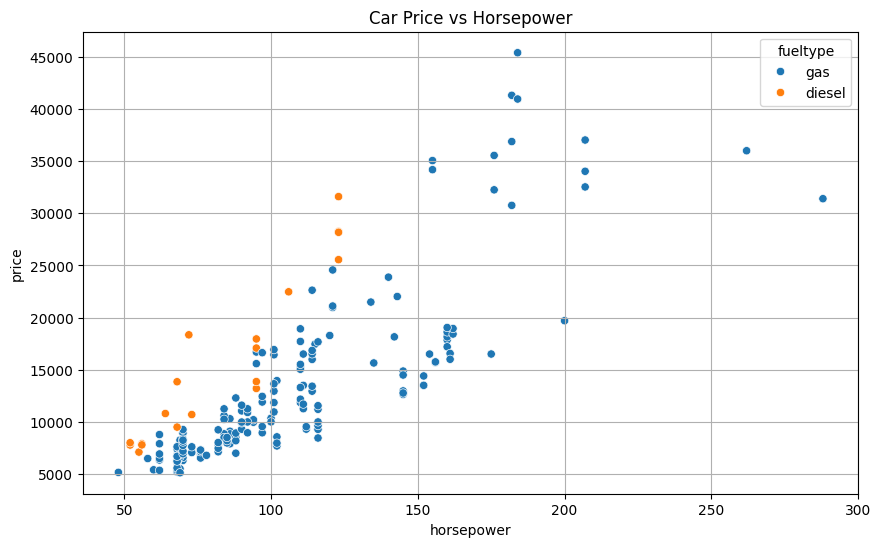

In [5]:
plt.figure(figsize=(10,6))
# Using 'horsepower' for X and 'price' for Y based on your index
sns.scatterplot(data=df, x='horsepower', y='price', hue='fueltype')
plt.title('Car Price vs Horsepower')
plt.grid(True)
plt.show()

In [6]:
# Selecting the most relevant numeric features for our model
features = ['symboling', 'wheelbase', 'carlength', 'carwidth', 'curbweight', 
            'enginesize', 'boreratio', 'horsepower', 'citympg', 'highwaympg']

X = df[features]
Y = df['price']

# Split the data
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print("Data split successfully!")

Data split successfully!


In [7]:
# Initialize and train
model = LinearRegression()
model.fit(X_train, Y_train)

# Predict
predictions = model.predict(X_test)

# Check Accuracy
score = r2_score(Y_test, predictions)
print(f"Model R-squared Score: {score:.4f}")

Model R-squared Score: 0.8189
